# L1.3 — Learning Rate

Hands-on notebook for the lesson [`1-3-learning-rate.mdx`](../../llm-quest-theory/level-1/1-3-learning-rate.mdx).

> **Learning objectives**
> - Observe all three regimes (too small, just right, too large, diverging) on the same problem.
> - Implement a simple cosine-annealing schedule and a linear warmup.
> - Build a minimal Adam optimizer by hand and compare against plain SGD.

## Connection to the theory
Covers **§1–§6** of the source `.mdx`. Learning rate is the single knob that decides whether training works at all — understanding its shape makes tuning feel less like guesswork.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. A single problem, four learning rates
We reuse the anisotropic bowl from lesson 1-2: `f(x, y) = 0.5 * (x^2 + 3 y^2)`.

In [2]:
def f(v):
    x, y = v
    return 0.5 * (x ** 2 + 3 * y ** 2)

def grad(v):
    x, y = v
    return np.array([x, 3 * y])

def run_gd(lr, n_steps=80, v0=(-3.0, 2.0)):
    v = np.array(v0, dtype=float)
    losses = [f(v)]
    for _ in range(n_steps):
        v = v - lr * grad(v)
        losses.append(f(v))
    return np.array(losses)

regimes = {
    "too small  (lr=0.01)": 0.01,
    "just right (lr=0.15)": 0.15,
    "too large  (lr=0.55)": 0.55,
    "diverging  (lr=0.70)": 0.70,
}
losses = {name: run_gd(lr) for name, lr in regimes.items()}
for name, ls in losses.items():
    tail = ls[-1] if np.isfinite(ls[-1]) else float("inf")
    print(f"{name}: final loss = {tail:.4g}")

too small  (lr=0.01): final loss = 0.9471
just right (lr=0.15): final loss = 2.292e-11
too large  (lr=0.55): final loss = 6.987e-30
diverging  (lr=0.70): final loss = 2.518e+07


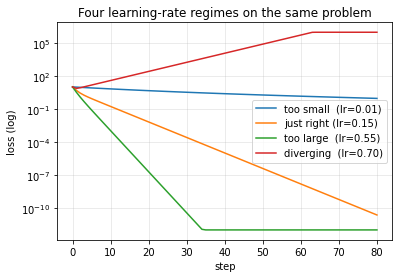

In [3]:
fig, ax = plt.subplots()
for name, ls in losses.items():
    ax.plot(np.clip(ls, 1e-12, 1e6), label=name)
ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("loss (log)")
ax.grid(alpha=0.3, which="both"); ax.legend()
ax.set_title("Four learning-rate regimes on the same problem")
plt.show()

Observations:
- Too small: loss drops monotonically but very slowly.
- Just right: smooth exponential decay.
- Too large: oscillates, but still decays.
- Diverging: loss grows without bound (and would hit `inf` quickly).

## 2. Fine-grained sweep
Sweep `lr` from `1e-3` to `~1` and measure the loss after a fixed budget of steps. This is a classic "LR finder" style plot.

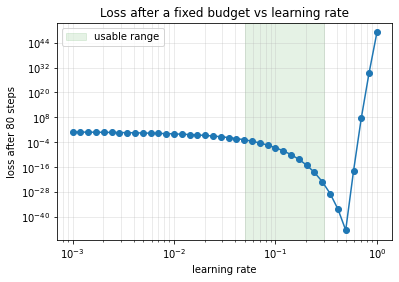

In [4]:
lrs = np.logspace(-3, 0, 40)
final_losses = []
for lr in lrs:
    ls = run_gd(lr, n_steps=80)
    final_losses.append(ls[-1] if np.isfinite(ls[-1]) else 1e12)

fig, ax = plt.subplots()
ax.plot(lrs, final_losses, "o-")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("learning rate"); ax.set_ylabel("loss after 80 steps")
ax.axvspan(0.05, 0.3, alpha=0.1, color="green", label="usable range")
ax.grid(alpha=0.3, which="both"); ax.legend()
ax.set_title("Loss after a fixed budget vs learning rate")
plt.show()

## 3. Learning rate schedules
Three popular shapes, all built in a few lines.

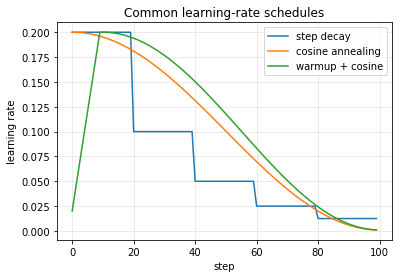

In [5]:
def step_decay(t, lr0=0.2, every=20, gamma=0.5):
    return lr0 * (gamma ** (t // every))

def cosine_annealing(t, T=100, lr_max=0.2, lr_min=1e-3):
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * t / T))

def warmup_cosine(t, T=100, warmup=10, lr_max=0.2, lr_min=1e-3):
    if t < warmup:
        return lr_max * (t + 1) / warmup
    return cosine_annealing(t - warmup, T - warmup, lr_max, lr_min)

T = 100
t_axis = np.arange(T)
fig, ax = plt.subplots()
ax.plot(t_axis, [step_decay(t) for t in t_axis],       label="step decay")
ax.plot(t_axis, [cosine_annealing(t, T) for t in t_axis], label="cosine annealing")
ax.plot(t_axis, [warmup_cosine(t, T) for t in t_axis], label="warmup + cosine")
ax.set_xlabel("step"); ax.set_ylabel("learning rate")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("Common learning-rate schedules")
plt.show()

## 4. Put a schedule to work
Run GD on the bowl with a fixed `lr=0.2` vs a cosine schedule peaking at the same value.

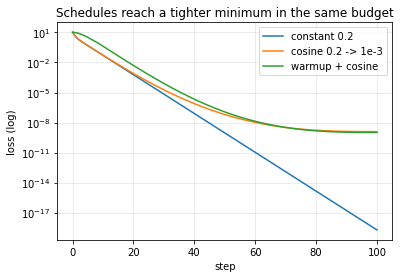

In [6]:
def run_with_schedule(schedule_fn, n_steps=100, v0=(-3.0, 2.0)):
    v = np.array(v0, dtype=float)
    losses = [f(v)]
    for t in range(n_steps):
        lr_t = schedule_fn(t)
        v = v - lr_t * grad(v)
        losses.append(f(v))
    return np.array(losses)

loss_const   = run_with_schedule(lambda t: 0.2, n_steps=100)
loss_cosine  = run_with_schedule(lambda t: cosine_annealing(t, 100, 0.2, 1e-3))
loss_warmup  = run_with_schedule(lambda t: warmup_cosine(t, 100, 10, 0.2, 1e-3))

fig, ax = plt.subplots()
ax.plot(loss_const,  label="constant 0.2")
ax.plot(loss_cosine, label="cosine 0.2 -> 1e-3")
ax.plot(loss_warmup, label="warmup + cosine")
ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("loss (log)")
ax.grid(alpha=0.3); ax.legend()
ax.set_title("Schedules reach a tighter minimum in the same budget")
plt.show()

## 5. Minimal Adam optimizer
Adam keeps per-parameter running statistics of the first moment (`m`, mean) and second moment (`v`, uncentered variance), which acts like a per-parameter adaptive learning rate.

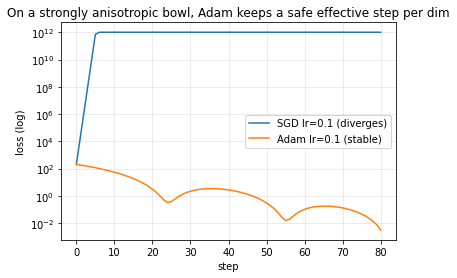

In [7]:
# Build a genuinely anisotropic bowl where SGD has trouble but Adam thrives.
def f_hard(v):    x, y = v; return 0.5 * (x ** 2 + 100 * y ** 2)
def grad_hard(v): x, y = v; return np.array([x, 100 * y])

def run_gd_on(f_fn, grad_fn, lr, n_steps=80, v0=(-3.0, 2.0)):
    v = np.array(v0, dtype=float); losses = [f_fn(v)]
    for _ in range(n_steps):
        v = v - lr * grad_fn(v); losses.append(f_fn(v))
    return np.array(losses)

def run_adam(f_fn, grad_fn, lr, n_steps=80, beta1=0.9, beta2=0.999, eps=1e-8, v0=(-3.0, 2.0)):
    v = np.array(v0, dtype=float)
    m = np.zeros_like(v); s = np.zeros_like(v)
    losses = [f_fn(v)]
    for t in range(1, n_steps + 1):
        g = grad_fn(v)
        m = beta1 * m + (1 - beta1) * g
        s = beta2 * s + (1 - beta2) * (g * g)
        m_hat = m / (1 - beta1 ** t)
        s_hat = s / (1 - beta2 ** t)
        v = v - lr * m_hat / (np.sqrt(s_hat) + eps)
        losses.append(f_fn(v))
    return np.array(losses)

# Same learning rate for both — SGD cannot stay stable here.
LR = 0.1
loss_sgd  = np.clip(run_gd_on(f_hard, grad_hard, LR, n_steps=80), 1e-12, 1e12)
loss_adam = run_adam(f_hard, grad_hard, LR, n_steps=80)

fig, ax = plt.subplots()
ax.plot(loss_sgd,  label=f"SGD lr={LR} (diverges)")
ax.plot(loss_adam, label=f"Adam lr={LR} (stable)")
ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("loss (log)")
ax.grid(alpha=0.3); ax.legend()
ax.set_title("On a strongly anisotropic bowl, Adam keeps a safe effective step per dim")
plt.show()

## 6. Diagnosis table
A compact version of the table from the theory — useful as a debugging cheatsheet.

In [8]:
rows = [
    ("Loss decreases slowly",          "lr too small",       "Increase lr 2x-5x"),
    ("Loss oscillates",                "lr too large",       "Decrease lr /2 to /10"),
    ("Loss becomes NaN / diverges",    "lr way too large",   "Decrease lr /10 + add grad clipping"),
    ("Loss plateaus late in training", "Needs a scheduler",  "Add cosine decay"),
]
print(f"{'Symptom':<36} {'Diagnosis':<22} {'Action'}")
print("-" * 90)
for s, d, a in rows:
    print(f"{s:<36} {d:<22} {a}")

Symptom                              Diagnosis              Action
------------------------------------------------------------------------------------------
Loss decreases slowly                lr too small           Increase lr 2x-5x
Loss oscillates                      lr too large           Decrease lr /2 to /10
Loss becomes NaN / diverges          lr way too large       Decrease lr /10 + add grad clipping
Loss plateaus late in training       Needs a scheduler      Add cosine decay


## 7. Quick checks

In [9]:
assert losses["just right (lr=0.15)"][-1] < losses["too small  (lr=0.01)"][-1]
assert losses["diverging  (lr=0.70)"][-1] > 100, "lr=0.7 should diverge on this bowl"
assert loss_cosine[-1] < 1e-3, "cosine schedule should reach a small loss"
assert loss_warmup[-1] < 1e-3, "warmup+cosine should also reach a small loss"
assert loss_adam[-1] < 1.0,     "Adam should converge on the anisotropic bowl"
assert loss_sgd[-1]  > loss_adam[-1] * 100, "SGD at lr=0.1 should blow up while Adam does not"
print("OK — all learning-rate regimes behave as expected.")

OK — all learning-rate regimes behave as expected.


## Reflection questions

1. In section 1, loss for `lr=0.55` oscillates but still decreases. Why doesn't it diverge like `lr=0.7`? (Think about the second derivative of `f`.)
2. For deep networks, why is *warmup* typically needed even when the final learning rate would otherwise be stable?
3. Adam works well here with `lr=0.2`, which blows up in plain SGD. Which piece of Adam's update rule is responsible for this?

## References
- Source theory: [`1-3-learning-rate.mdx`](../../llm-quest-theory/level-1/1-3-learning-rate.mdx)
- Next: [`1-4-probability`](1-4-probability.ipynb)